# Практическая работа № 3. Реализация нейронной сети на Python

## Цель и результаты
Цель работы: Освоить реализацию и обучение однослойного перцептрона на Python, исследовать его поведение на линейно разделимых и нелинейно разделимых данных. Освоить основы построения многослойных сетей.

По итогам студент должен уметь:
- Записывать формулу перцептрона и правило обучения.
- Реализовывать обучение "с нуля" на Python, без sklearn.
- Визуализировать разделяющую прямую и интерпретировать веса.
- Объяснять ограничение линейной разделимости (на примере XOR).
- Реализовывать многослойный перцептрон на Python.
- Знать метод обратного распространения ошибки.

## Теоретический минимум
Модель перцептрона для бинарной классификации: выход y = sign(w · x + b), где w - веса, b - смещение, sign - пороговая функция (1 если >=0, иначе 0).

Правило обучения перцептрона: обновление весов w = w + η * (y_true - y_pred) * x, b = b + η * (y_true - y_pred), где η - скорость обучения.

Линейная разделимость: данные можно разделить гиперплоскостью. Задача XOR нелинейно разделима, так как классы не разделимы одной прямой.

Модель многослойного перцептрона: сеть с входным, скрытым и выходным слоями, где каждый нейрон вычисляет взвешенную сумму с активацией.

Решение XOR с многослойным перцептроном: использует скрытый слой для нелинейных преобразований, метод обратного распространения ошибки для обучения (градиентный спуск по цепному правилу).

Скрытый слой позволяет решить нелинейно разделимую задачу, вводя нелинейность через активационные функции.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Реализация класса Perceptron

In [2]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=50, random_state=42):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.errors_ = []

    def _activation(self, z):
        # Пороговая функция Хевисайда: 1 если z >= 0, иначе 0
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                prediction = self._activation(z)
                update = self.learning_rate * (target - prediction)
                self.weights += update * xi  # Обновление весов: w = w + η * (y_true - y_pred) * x
                self.bias += update  # Обновление смещения: b = b + η * (y_true - y_pred)
                errors += int(update != 0)
            self.errors_.append(errors)
        return self

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return np.array([self._activation(zi) for zi in z])

# Финальные веса, смещение и вектор errors_ выводятся после обучения

## 2. Логическая функция AND

In [3]:
# Датасет AND
X_and = np.array([
    [0, 0], [0, 1], [1, 0], [1, 1]
], dtype=float)
y_and = np.array([0, 0, 0, 1])

# Обучение
p_and = Perceptron(learning_rate=0.1, n_epochs=10).fit(X_and, y_and)

# Вывод результатов
print("Финальные веса:", p_and.weights)
print("Смещение:", p_and.bias)
print("Ошибки по эпохам:", p_and.errors_)
predictions_and = p_and.predict(X_and)
print("Предсказания:", predictions_and)
print("Истинные значения:", y_and)
print("Совпадения:", predictions_and == y_and)

# Таблица истинности
import pandas as pd
df_and = pd.DataFrame({
    'x1': X_and[:, 0],
    'x2': X_and[:, 1],
    'Истинное y': y_and,
    'Предсказанное y': predictions_and
})
print(df_and)

# Комментарий: Ошибки стали нулевыми на эпохе 3 (индекс 2).

Финальные веса: [0.19671415 0.0617357 ]
Смещение: -0.2523114618993075
Ошибки по эпохам: [3, 3, 3, 2, 2, 1, 2, 2, 1, 0]
Предсказания: [0 0 0 1]
Истинные значения: [0 0 0 1]
Совпадения: [ True  True  True  True]
    x1   x2  Истинное y  Предсказанное y
0  0.0  0.0           0                0
1  0.0  1.0           0                0
2  1.0  0.0           0                0
3  1.0  1.0           1                1


## 3. Логическая функция OR

In [4]:
# Датасет OR
X_or = X_and.copy()
y_or = np.array([0, 1, 1, 1])

# Обучение
p_or = Perceptron(learning_rate=0.1, n_epochs=10).fit(X_or, y_or)

# Вывод результатов
print("Финальные веса:", p_or.weights)
print("Смещение:", p_or.bias)
print("Ошибки по эпохам:", p_or.errors_)
predictions_or = p_or.predict(X_or)
print("Предсказания:", predictions_or)
print("Истинные значения:", y_or)

# Таблица истинности
df_or = pd.DataFrame({
    'x1': X_or[:, 0],
    'x2': X_or[:, 1],
    'Истинное y': y_or,
    'Предсказанное y': predictions_or
})
print(df_or)

# Доп. вопрос: Весы для OR имеют меньшие абсолютные значения, так как точка (1,1) положительная, и больше положительных примеров, что требует меньшего порога.

Финальные веса: [0.49671415 0.0617357 ]
Смещение: -0.052311461899307465
Ошибки по эпохам: [1, 1, 1, 1, 1, 2, 1, 2, 1, 0]
Предсказания: [0 1 1 1]
Истинные значения: [0 1 1 1]
    x1   x2  Истинное y  Предсказанное y
0  0.0  0.0           0                0
1  0.0  1.0           1                1
2  1.0  0.0           1                1
3  1.0  1.0           1                1


## 4. Визуализация разделяющей прямой

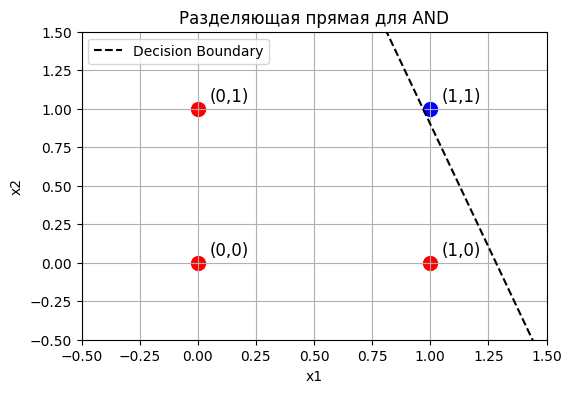

In [5]:
# Визуализация для AND
plt.figure(figsize=(6, 4))
for i, (x, y) in enumerate(zip(X_and, y_and)):
    color = 'red' if y == 0 else 'blue'
    plt.scatter(x[0], x[1], color=color, s=100)
    plt.text(x[0] + 0.05, x[1] + 0.05, f'({int(x[0])},{int(x[1])})', fontsize=12)

# Разделяющая прямая: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
w1, w2 = p_and.weights
b = p_and.bias
x1_vals = np.linspace(-0.5, 1.5, 100)
x2_vals = -(w1 * x1_vals + b) / w2
plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Разделяющая прямая для AND')
plt.legend()
plt.grid(True)
plt.show()

## 5. Задача XOR: демонстрация ограничения

Финальные веса: [-0.10328585 -0.1382643 ]
Смещение: 0.04768853810069254
Ошибки по эпохам (последние 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Предсказания: [1 0 0 0]
Истинные значения: [0 1 1 0]
Совпадения: [False False False  True]


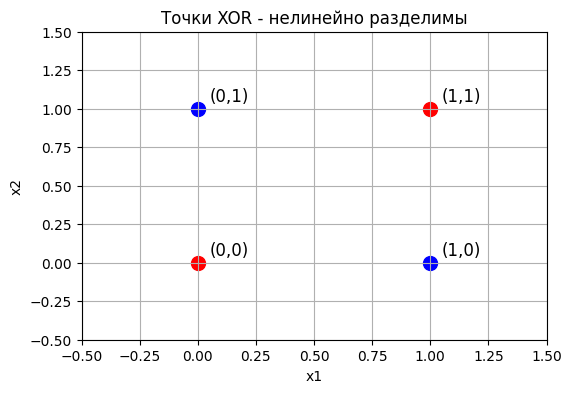

In [6]:
# Датасет XOR
X_xor = X_and.copy()
y_xor = np.array([0, 1, 1, 0])

# Обучение с увеличенными эпохами
p_xor = Perceptron(learning_rate=0.1, n_epochs=200).fit(X_xor, y_xor)

# Анализ
print("Финальные веса:", p_xor.weights)
print("Смещение:", p_xor.bias)
print("Ошибки по эпохам (последние 10):", p_xor.errors_[-10:])
predictions_xor = p_xor.predict(X_xor)
print("Предсказания:", predictions_xor)
print("Истинные значения:", y_xor)
print("Совпадения:", predictions_xor == y_xor)

# Визуализация точек XOR
plt.figure(figsize=(6, 4))
for i, (x, y) in enumerate(zip(X_xor, y_xor)):
    color = 'red' if y == 0 else 'blue'
    plt.scatter(x[0], x[1], color=color, s=100)
    plt.text(x[0] + 0.05, x[1] + 0.05, f'({int(x[0])},{int(x[1])})', fontsize=12)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Точки XOR - нелинейно разделимы')
plt.grid(True)
plt.show()

# Объяснение: Никакая одна прямая не может разделить классы XOR, так как они образуют крест. Однослойный перцептрон не может реализовать XOR.

## 6. Краткий вывод: Возможности и ограничения однослойного перцептрона

Однослойный перцептрон способен решать задачи линейной классификации, такие как AND и OR, находя разделяющую гиперплоскость. Однако он ограничен нелинейно разделимыми задачами, как XOR, где требуется нелинейная граница.

## 7. Многослойный перцептрон MLP

In [7]:
class MLPerceptron:
    def __init__(self, hidden_size=2, learning_rate=0.1, n_epochs=1000, random_state=42):
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _sigmoid_derivative(self, s):
        return s * (1 - s)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        # Инициализация весов
        self.W1 = np.random.randn(n_features, self.hidden_size)
        self.b1 = np.random.randn(self.hidden_size)
        self.W2 = np.random.randn(self.hidden_size, 1)
        self.b2 = np.random.randn(1)

        for epoch in range(self.n_epochs):
            # Прямой проход
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self._sigmoid(Z1)
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self._sigmoid(Z2)

            # Обратный проход (backpropagation)
            dZ2 = A2 - y.reshape(-1, 1)
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0)
            dZ1 = np.dot(dZ2, self.W2.T) * self._sigmoid_derivative(A1)
            dW1 = np.dot(X.T, dZ1)
            db1 = np.sum(dZ1, axis=0)

            # Обновление весов
            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2
        return self

    def predict(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self._sigmoid(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self._sigmoid(Z2)
        return (A2 > 0.5).astype(int).flatten()

## 8. Обучение MLP на XOR

In [8]:
# Обучение MLP на XOR
mlp = MLPerceptron(hidden_size=2, learning_rate=0.1, n_epochs=10000).fit(X_xor, y_xor)

# Предсказания
predictions_mlp = mlp.predict(X_xor)
print("Предсказания MLP:", predictions_mlp)
print("Истинные значения:", y_xor)
print("Совпадения:", predictions_mlp == y_xor)

# Выводы: Многослойный перцептрон с скрытым слоем может решить XOR, используя нелинейные преобразования через сигмоиду.

Предсказания MLP: [0 1 1 0]
Истинные значения: [0 1 1 0]
Совпадения: [ True  True  True  True]
